In [2]:

import random, pickle, mygene
import pandas as pd, numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, train_test_split
from xgboost import XGBClassifier
# import sentence_transformers
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina') # for high resolution plots
sns.set_style("whitegrid")
plt.style.use('ggplot') # plt.style.use('seaborn-v0_8-dark-palette')
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams.update({"text.usetex": False, "font.family": "Helvetica"})

In [ ]:
# Gene Embeddings of GenePT
with open("./input_data/GenePT_embedding/GPT_3_5_gene_embeddings.pickle", "rb") as fp:
    gene_embeddings_of_genept = pickle.load(fp)

# Gene Embeddings of random generation
gene_embeddings_of_random = dict()
np.random.seed(2023)
for key in gene_embeddings_of_genept.keys():
    gene_embeddings_of_random[key] = np.random.normal(size=(1536))

# Gene Embeddings of Gene2vec
gene2vec_embeddings = pd.read_csv('./input_data/gene2vec/gene2vec_dim_200_iter_9.txt', header=None, sep='\t')
gene_embeddings_of_gene2vec = {}  # Dictionary to hold gene_name: 200-dimensional vector
for index, row in gene2vec_embeddings.iterrows():
    gene_name = row[0]; vector_str = row[1]; vector = [float(x) for x in vector_str.split()]  
    if len(vector) == 200:  # Ensure the row has exactly 200 numbers
        gene_embeddings_of_gene2vec[gene_name] = np.array(vector)

# Long- vs short- range TFs classification

The input data used here are downloaded from Chen et al, "Determinants of transcription factor regulatory range", 2020. (link: https://www.nature.com/articles/s41467-020-16106-x).

In [9]:
long_short_range_tf = pd.read_csv('./input_data/41467_2020_16106_MOESM4_ESM.csv')
long_range_tf_gene = list(long_short_range_tf[long_short_range_tf['assignment']=='long-range TF']['Unnamed: 0'])
short_range_tf_gene = list(long_short_range_tf[long_short_range_tf['assignment']=='short-range TF']['Unnamed: 0'])
x_long_range_tf = [gene_embeddings_of_genept[x] for x in long_range_tf_gene if x in gene_embeddings_of_genept]
x_short_range_tf =  [gene_embeddings_of_genept[x] for x in short_range_tf_gene if x in gene_embeddings_of_genept]
X_array = np.concatenate((x_long_range_tf, x_short_range_tf))
y_array =  np.concatenate((np.repeat(1, len(x_long_range_tf)), np.repeat(0, len(x_short_range_tf))))
cv = StratifiedKFold(n_splits=5, shuffle=False, random_state=None) 
roc_auc_lr = []; roc_auc_rf = []
for train_index, test_index in cv.split(X_array, y_array):
    X_train, X_test = X_array[train_index], X_array[test_index]
    y_train, y_test = y_array[train_index], y_array[test_index]
    # Logistic Regression
    logistic_model = LogisticRegression()
    logistic_model.fit(X_train, y_train)
    y_score_lr = logistic_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score_lr)
    roc_auc = auc(fpr, tpr)
    roc_auc_lr.append(roc_auc)
    # Random Forest
    random_forest_model = RandomForestClassifier()
    random_forest_model.fit(X_train, y_train)
    y_score_rf = random_forest_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score_rf)
    roc_auc = auc(fpr, tpr)
    roc_auc_rf.append(roc_auc)
print(f"Logistic Regression ROC AUC: {np.mean(roc_auc_lr):.3f} +/- {np.std(roc_auc_lr):.3f}")
print(f"Random Forest ROC AUC: {np.mean(roc_auc_rf):.3f} +/- {np.std(roc_auc_rf):.3f}")

Logistic Regression ROC AUC: 0.726 +/- 0.261
Random Forest ROC AUC: 0.695 +/- 0.176


# Dosage sensitive vs insensitive TFs classification

The input data used here are downloaded from Theodoris et al, "Transfer learning enables predictions in network biology (Geneformer)", 2023. (link: https://www.nature.com/articles/s41586-023-06139-9; https://huggingface.co/ctheodoris/Geneformer; https://huggingface.co/datasets/ctheodoris/Genecorpus-30M).

1 input query terms found no hit:	['ENSG00000215271']


Logistic Regression ROC AUC: 0.888 +/- 0.029
Random Forest ROC AUC: 0.907 +/- 0.028


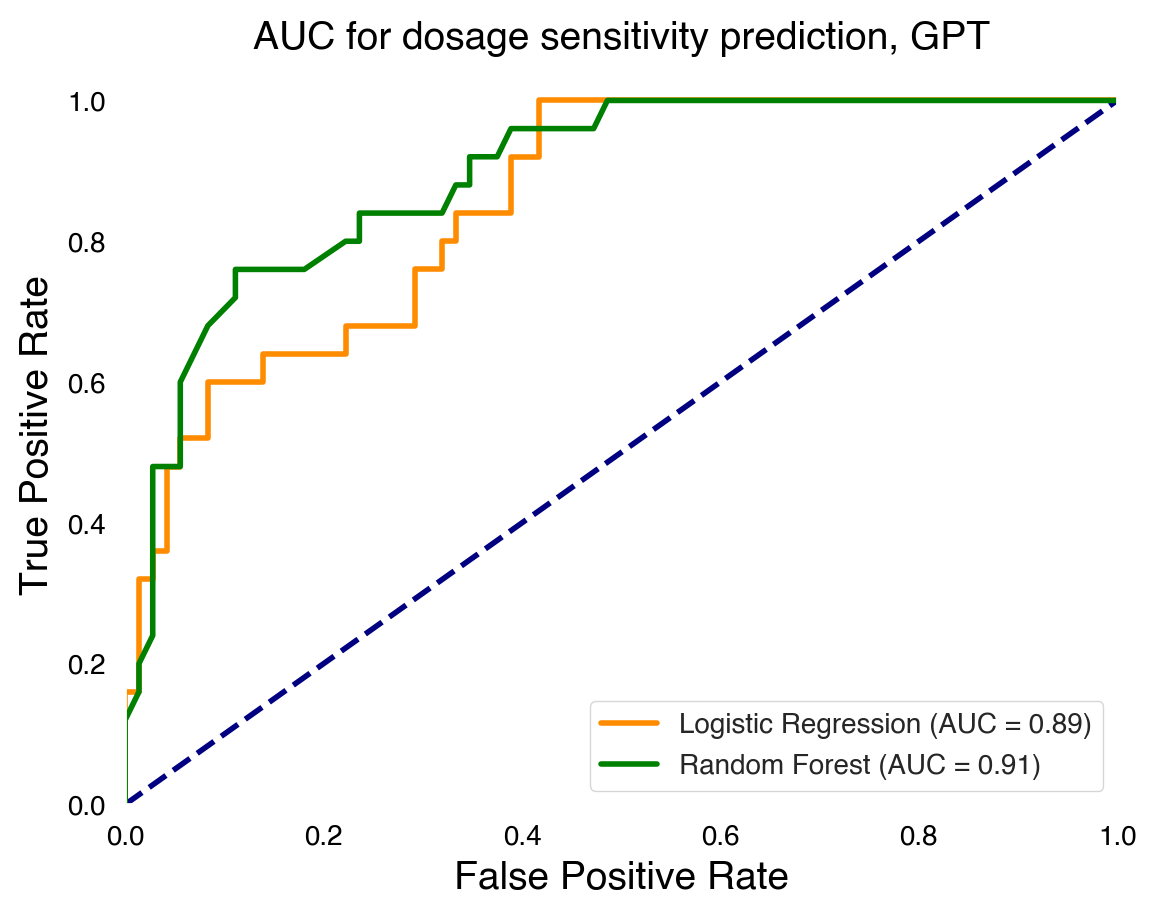

In [18]:
dosage_tfs = pd.read_csv("./input_data/dosage_sens_tf_labels.csv", header=0)
sensitive = dosage_tfs["dosage_sensitive"].dropna()
insensitive = dosage_tfs["dosage_insensitive"].dropna()
mg = mygene.MyGeneInfo()
sensitive_query = mg.querymany(sensitive, species='human')
insensitive_query = mg.querymany(insensitive, species='human')
sensitive_gene_name = [x['symbol'] for x in sensitive_query if 'symbol' in x]
insensitive_gene_name = [x['symbol'] for x in insensitive_query if 'symbol' in x]
x_sensitive = [gene_embeddings_of_genept[name] for name in sensitive_gene_name if name in gene_embeddings_of_genept]
x_insensitive = [gene_embeddings_of_genept[name] for name in insensitive_gene_name if name in gene_embeddings_of_genept]
X_array = np.concatenate((x_sensitive, x_insensitive))
y_array = np.concatenate((np.repeat(1, len(x_sensitive)), np.repeat(0, len(x_insensitive))))
cv = StratifiedKFold(n_splits=5, shuffle=False, random_state=None) # get the cross-validation indices with stratified sampling
roc_auc_lr = []; roc_auc_rf = []; tpr_lr = []; fpr_lr = []; tpr_rf = []; fpr_rf = []
for train_index, test_index in cv.split(X_array, y_array):
    X_train, X_test = X_array[train_index], X_array[test_index]
    y_train, y_test = y_array[train_index], y_array[test_index]
    # Logistic Regression
    logistic_model = LogisticRegression()
    logistic_model.fit(X_train, y_train)
    y_score_logistic = logistic_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score_logistic)
    roc_auc = auc(fpr, tpr)
    roc_auc_lr.append(roc_auc)
    tpr_lr.append(tpr); fpr_lr.append(fpr)
    # Random Forest
    random_forest_model = RandomForestClassifier()
    random_forest_model.fit(X_train, y_train)
    y_score_rf = random_forest_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score_rf)
    roc_auc = auc(fpr, tpr)
    roc_auc_rf.append(roc_auc)
    tpr_rf.append(tpr); fpr_rf.append(fpr)
print(f"Logistic Regression ROC AUC: {np.mean(roc_auc_lr):.3f} +/- {np.std(roc_auc_lr):.3f}")
print(f"Random Forest ROC AUC: {np.mean(roc_auc_rf):.3f} +/- {np.std(roc_auc_rf):.3f}")

# Plot ROC curves
plt.figure()
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.plot(fpr_lr[0], tpr_lr[0], color='darkorange', lw=2, label='Logistic Regression (AUC = %0.2f)' % np.mean(roc_auc_lr))
plt.plot(fpr_rf[0], tpr_rf[0], color='green', lw=2, label='Random Forest (AUC = %0.2f)' % np.mean(roc_auc_rf))
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xticks(color='black'); plt.yticks(color='black')
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold', color='black')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold', color='black')
plt.title('AUC for dosage sensitivity prediction, GPT', fontsize=14, fontweight='bold', color='black')
plt.legend(loc='lower right')
plt.show()

# Methylation state prediction

- Bivalent versus non-methylated
- Bivalent versus lys-4 methylated

The input data used here are downloaded from Theodoris et al, "Transfer learning enables predictions in network biology (Geneformer)", 2023. (link: https://www.nature.com/articles/s41586-023-06139-9; https://huggingface.co/ctheodoris/Geneformer; https://huggingface.co/datasets/ctheodoris/Genecorpus-30M).

In [19]:
bivalent_gene_labels = pd.read_csv('./input_data/bivalent_gene_labels.txt',header=None)
no_methylation_gene_labels = pd.read_csv('./input_data/no_methylation_gene_labels.txt',header=None)
lysine_gene_labels = pd.read_csv('./input_data/lys4_only_gene_labels.txt',header=None)
bivalent_query = mg.querymany(list(bivalent_gene_labels[0]), species='human')
no_methylation_query = mg.querymany(list(no_methylation_gene_labels[0]), species='human')
lysine_query = mg.querymany(list(lysine_gene_labels[0]), species='human')
x_bivalent = [gene_embeddings_of_genept[x['symbol']] for x in bivalent_query if 'symbol' in x and x['symbol'] in gene_embeddings_of_genept]
x_no_methylation = [gene_embeddings_of_genept[x['symbol']] for x in no_methylation_query if 'symbol' in x and  x['symbol'] in gene_embeddings_of_genept]
x_lysine = [gene_embeddings_of_genept[x['symbol']] for x in lysine_query if 'symbol' in x and  x['symbol'] in gene_embeddings_of_genept]

### Bivalent versus non-methylated
X_array = np.concatenate((x_bivalent, x_no_methylation))
y_array = np.concatenate((np.repeat(1, len(x_bivalent)), np.repeat(0, len(x_no_methylation))))
cv = StratifiedKFold(n_splits=5, shuffle=False, random_state=None)
roc_auc_lr = []; roc_auc_rf = []
for train_index, test_index in cv.split(X_array, y_array):
    X_train, X_test = X_array[train_index], X_array[test_index]
    y_train, y_test = y_array[train_index], y_array[test_index]
    # Logistic Regression
    logistic_model = LogisticRegression()
    logistic_model.fit(X_train, y_train)
    y_score_logistic = logistic_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score_logistic)
    roc_auc = auc(fpr, tpr)
    roc_auc_lr.append(roc_auc)
    # Random Forest
    random_forest_model = RandomForestClassifier()
    random_forest_model.fit(X_train, y_train)
    y_score_rf = random_forest_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score_rf)
    roc_auc = auc(fpr, tpr)
    roc_auc_rf.append(roc_auc)
print(f"Logistic Regression ROC AUC: {np.mean(roc_auc_lr):.3f} +/- {np.std(roc_auc_lr):.3f}")
print(f"Random Forest ROC AUC: {np.mean(roc_auc_rf):.3f} +/- {np.std(roc_auc_rf):.3f}")

### bivalent versus lys-4 methylated
X_array = np.concatenate((x_bivalent, x_lysine))
y_array = np.concatenate((np.repeat(1, len(x_bivalent)), np.repeat(0, len(x_lysine))))
cv = StratifiedKFold(n_splits=5, shuffle=False, random_state=None)
# Lists to store ROC AUC scores for each fold
roc_auc_lr = []; roc_auc_rf = []
for train_index, test_index in cv.split(X_array, y_array):
    X_train, X_test = X_array[train_index], X_array[test_index]
    y_train, y_test = y_array[train_index], y_array[test_index]
    # Logistic Regression
    logistic_model = LogisticRegression()
    logistic_model.fit(X_train, y_train)
    y_score_logistic = logistic_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score_logistic)
    roc_auc = auc(fpr, tpr)
    roc_auc_lr.append(roc_auc)
    # Random Forest
    random_forest_model = RandomForestClassifier()
    random_forest_model.fit(X_train, y_train)
    y_score_rf = random_forest_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score_rf)
    roc_auc = auc(fpr, tpr)
    roc_auc_rf.append(roc_auc)
print(f"Logistic Regression ROC AUC: {np.mean(roc_auc_lr):.3f} +/- {np.std(roc_auc_lr):.3f}")
print(f"Random Forest ROC AUC: {np.mean(roc_auc_rf):.3f} +/- {np.std(roc_auc_rf):.3f}")

10 input query terms found dup hits:	[('ENSG00000007372', 2), ('ENSG00000110693', 2), ('ENSG00000117707', 2), ('ENSG00000120093', 2), ('E
2 input query terms found dup hits:	[('ENSG00000147488', 2), ('ENSG00000151322', 2)]
2 input query terms found dup hits:	[('ENSG00000196628', 2), ('ENSG00000198728', 2)]


Logistic Regression ROC AUC: 0.912 +/- 0.062
Random Forest ROC AUC: 0.924 +/- 0.073
Logistic Regression ROC AUC: 0.941 +/- 0.034
Random Forest ROC AUC: 0.947 +/- 0.045


# Gene type prediction

The input data used here are downloaded from Theodoris et al, "Transfer learning enables predictions in network biology (Geneformer)", 2023. (link: https://www.nature.com/articles/s41586-023-06139-9; https://huggingface.co/ctheodoris/Geneformer; https://huggingface.co/datasets/ctheodoris/Genecorpus-30M).

Training set size (X_train): 22686 
 Test set size (X_test): 9723


<Figure size 600x600 with 0 Axes>

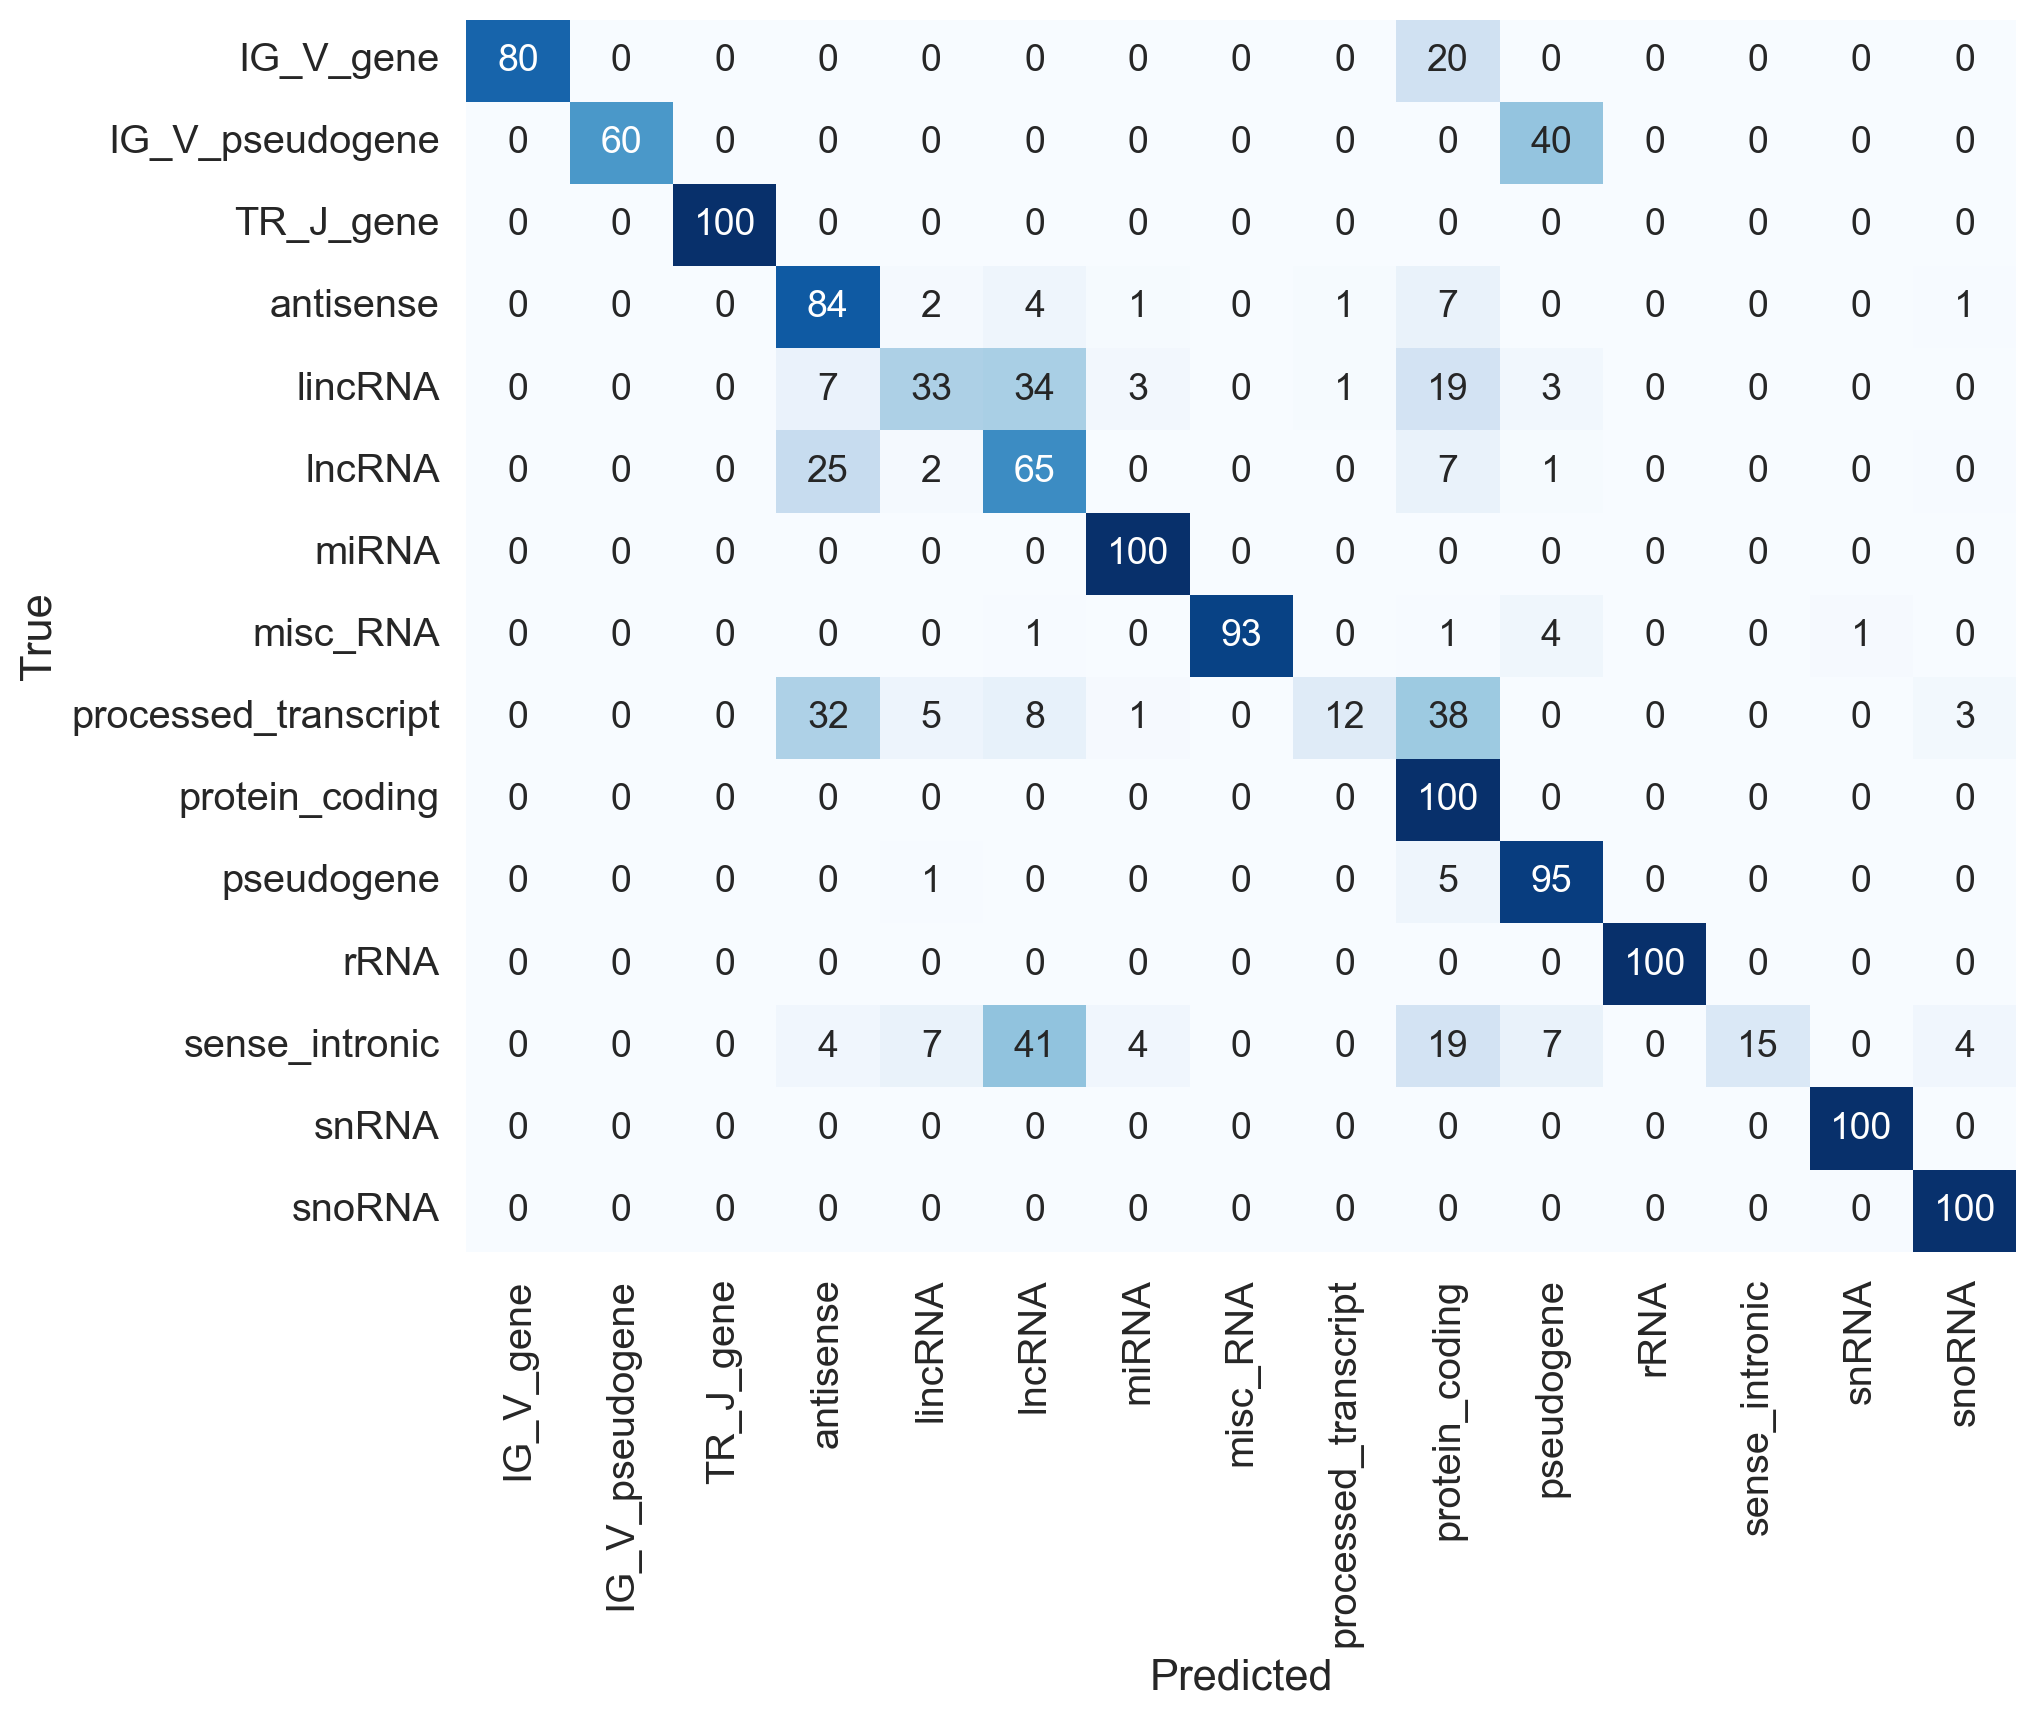

In [34]:
gene_info_table = pd.read_csv('./input_data/gene_info_table.csv')
gene_info_table['gpt_embed'] = gene_info_table['gene_name'].apply(lambda name: name in gene_embeddings_of_genept and np.any(gene_embeddings_of_genept[name] != 0))
gene_subset = gene_info_table[gene_info_table['gpt_embed']]
gene_subset_type_counts = gene_subset['gene_type'].value_counts()
common_gene_types = gene_subset_type_counts[gene_subset_type_counts > 75].index # Find gene_type elements with occurrences > 75
final_gene_subset = gene_info_table[(gene_info_table['gene_type'].isin(common_gene_types))&(gene_info_table['gpt_embed'])] # create a final subset of common gene types
X_list = []; y_list = []; 
for index, row in final_gene_subset.iterrows():
    X_list.append(gene_embeddings_of_genept[row['gene_name']]); y_list.append(row['gene_type'])
X_train, X_test, y_train, y_test = train_test_split(X_list, y_list, test_size=0.30, random_state=2023) # split the data into training and test sets (80/20)
print(f"Training set size (X_train): {len(X_train)} \n Test set size (X_test): {len(X_test)}")

lr = LogisticRegression(max_iter=100)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
metrics.accuracy_score(y_pred_lr,y_test) # calculate the accuracy of the logistic regression model
plt.figure(figsize=(6,6))
sns.set_theme(font_scale=1.3)
def plot_normalized_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # normalize the confusion matrix
    cm_normalized = np.nan_to_num(cm_normalized)  # replace nan with 0
    cm_normalized = cm_normalized * 100  # convert to percentage
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.0f', annot_kws={'fontsize': 13.5}, cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
plot_normalized_confusion_matrix(np.array(y_test), y_pred_lr, np.unique(y_list))

# Gene-gene interaction prediction

We showcase the gene-gene interaction prediction use case below. The input data can be downloaded from Gene2vec: distributed representation of genes based on co-expression. (link: https://github.com/jingcheng-du/Gene2vec; https://bmcgenomics.biomedcentral.com/articles/10.1186/s12864-018-5370-x)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Figure size 640x480 with 0 Axes>

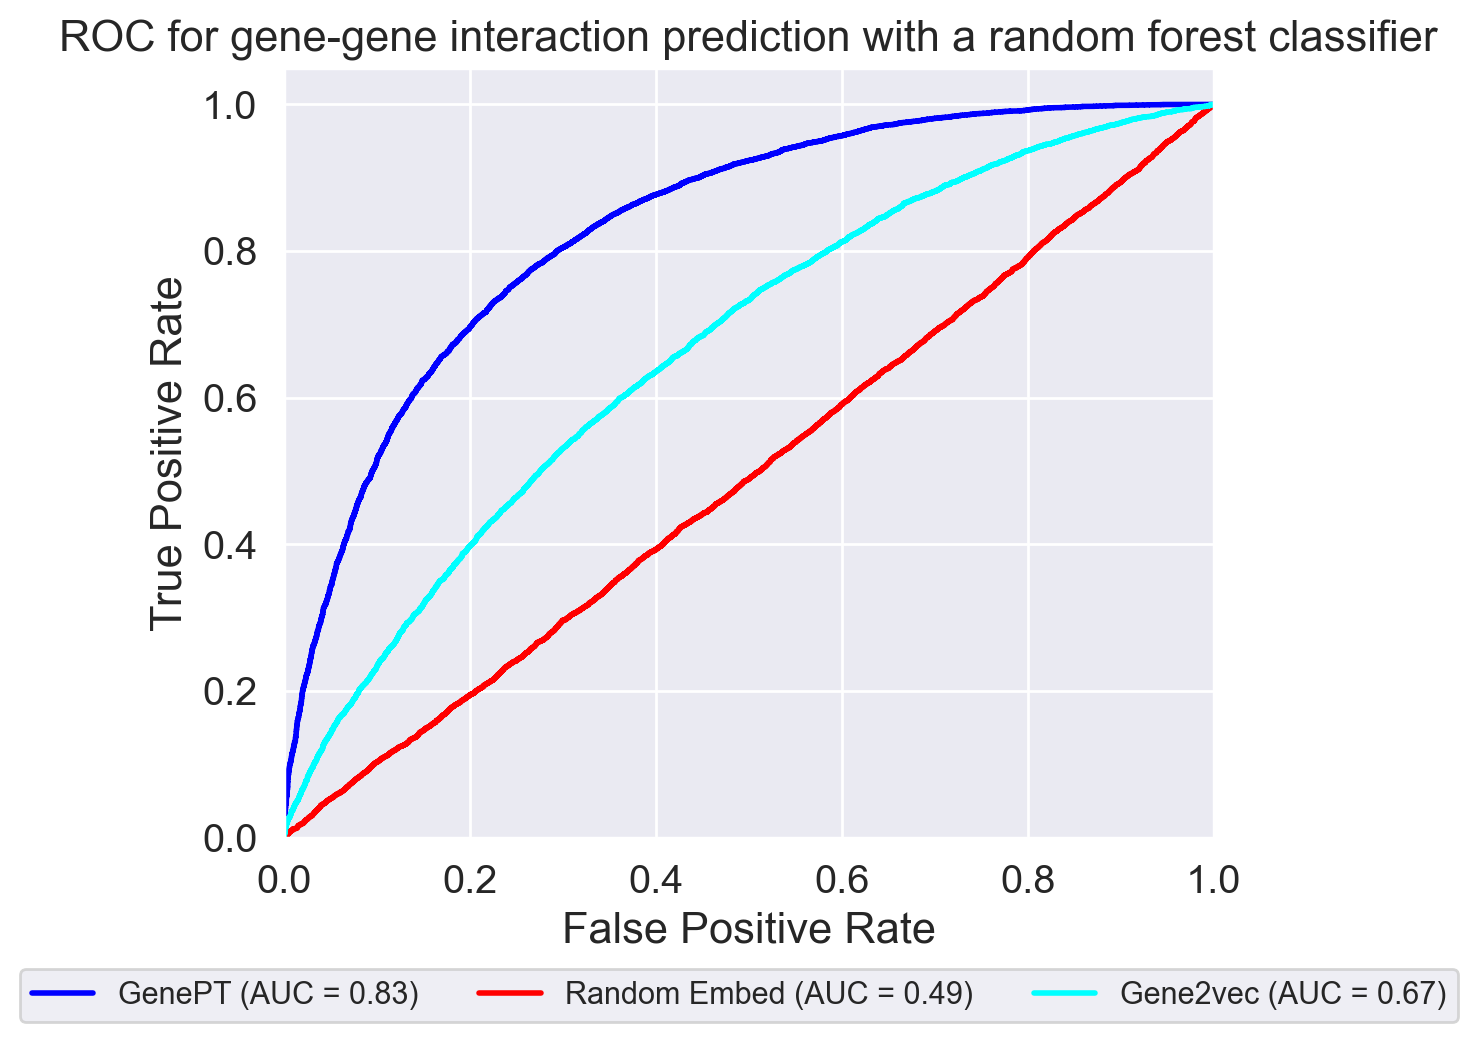

In [35]:
# gene gene interaction 
train_text_GGI = pd.read_csv('./input_data/gene2vec/train_text.txt', sep=' ', header=None)
train_label_GGI = pd.read_csv('./input_data/gene2vec/train_label.txt', header=None)
train_text_GGI_df = pd.concat([train_text_GGI, train_label_GGI], axis=1); train_text_GGI.columns = ['gene_1', 'gene_2', 'label']
test_text_GGI = pd.read_csv('./input_data/gene2vec/test_text.txt', sep=' ', header=None)
test_label_GGI = pd.read_csv('./input_data/gene2vec/test_label.txt', header=None)
test_text_GGI_df = pd.concat([test_text_GGI, test_label_GGI], axis=1); test_text_GGI_df.columns = ['gene_1', 'gene_2', 'label']

### We choose a simple featurization scheme by *adding* the emebdding vectors of the two genes together:
X_array_train = []; y_array_train = []; X_array_test = []; y_array_test = []
for i, row in train_text_GGI_df.iterrows():
    if row['gene_1'] in gene_embeddings_of_genept and row['gene_2'] in gene_embeddings_of_genept:
        X_array_train.append(gene_embeddings_of_genept[row['gene_1']]+gene_embeddings_of_genept[row['gene_2']])
        y_array_train.append(row['label'])
X_array_train = np.array(X_array_train); y_array_train = np.array(y_array_train); X_array_train = X_array_train.reshape(X_array_train.shape[0], -1)
for i, row in test_text_GGI_df.iterrows():
    if row['gene_1'] in  gene_embeddings_of_genept and row['gene_2'] in gene_embeddings_of_genept:
        X_array_test.append(gene_embeddings_of_genept[row['gene_1']]+gene_embeddings_of_genept[row['gene_2']])
        y_array_test.append(row['label'])
X_array_test = np.array(X_array_test); y_array_test = np.array(y_array_test); X_array_test = X_array_test.reshape(X_array_test.shape[0], -1)

X_array_test_random = []; y_array_test_random = []; X_array_train_random = []; y_array_train_random = []; 
for i, row in train_text_GGI_df.iterrows():
    if row['gene_1'] in  gene_embeddings_of_random and row['gene_2'] in gene_embeddings_of_random:
        X_array_train_random.append(gene_embeddings_of_random[row['gene_1']]+gene_embeddings_of_random[row['gene_2']])
        y_array_train_random.append(row['label'])
X_array_train_random = np.array(X_array_train_random); y_array_train_random = np.array(y_array_train_random); X_array_train_random = X_array_train_random.reshape(X_array_train_random.shape[0], -1)
for i, row in test_text_GGI_df.iterrows():
    if row['gene_1'] in  gene_embeddings_of_random and row['gene_2'] in gene_embeddings_of_random:
        X_array_test_random.append(gene_embeddings_of_random[row['gene_1']] + gene_embeddings_of_random[row['gene_2']])
        y_array_test_random.append(row['label'])
X_array_test_random = np.array(X_array_test_random); y_array_test_random = np.array(y_array_test_random); X_array_test_random = X_array_test_random.reshape(X_array_test_random.shape[0], -1)

X_array_train_gene2vec = []; y_array_train_gene2vec = []; X_array_test_gene2vec = []; y_array_test_gene2vec = []
for i, row in train_text_GGI_df.iterrows():
    if row['gene_1'] in  gene_embeddings_of_gene2vec and row['gene_2'] in gene_embeddings_of_gene2vec:
        X_array_train_gene2vec.append(gene_embeddings_of_gene2vec[row['gene_1']]+gene_embeddings_of_gene2vec[row['gene_2']])
        y_array_train_gene2vec.append(row['label'])
X_array_train_gene2vec = np.array(X_array_train_gene2vec); y_array_train_gene2vec = np.array(y_array_train_gene2vec); X_array_train_gene2vec = X_array_train_gene2vec.reshape(X_array_train_gene2vec.shape[0], -1)
for i, row in test_text_GGI_df.iterrows():
    if row['gene_1'] in  gene_embeddings_of_gene2vec and row['gene_2'] in gene_embeddings_of_gene2vec:
        X_array_test_gene2vec.append(gene_embeddings_of_gene2vec[row['gene_1']]+gene_embeddings_of_gene2vec[row['gene_2']])
        y_array_test_gene2vec.append(row['label'])
X_array_test_gene2vec = np.array(X_array_test_gene2vec); y_array_test_gene2vec = np.array(y_array_test_gene2vec); X_array_test_gene2vec = X_array_test_gene2vec.reshape(X_array_test_gene2vec.shape[0], -1)

### Replace the LogisticRegression() to RandomForest classifier to replace the results in the paper (slightly better AUC for GenePT and Gene2vec embeddings); we used the much faster LogisticRegression for illustration purposes here.  
rf_gene2vec = LogisticRegression()  # You can add hyperparameters like n_estimators if needed
rf_gene2vec.fit(X_array_train_gene2vec, y_array_train_gene2vec)
y_pred_rf_gene2vec = rf_gene2vec.predict_proba(X_array_test_gene2vec)
rf_random = LogisticRegression()  # You can add hyperparameters like n_estimators if needed
rf_random.fit(X_array_train_random, y_array_train_random)
y_pred_rf_random = rf_random.predict_proba(X_array_test_random)
rf = LogisticRegression()  # You can add hyperparameters like n_estimators if needed
rf.fit(X_array_train, y_array_train)
y_pred_rf = rf.predict_proba(X_array_test)
fpr_rf, tpr_rf, _ = roc_curve(y_array_test, y_pred_rf[:, 1])
fpr_random_rf, tpr_random_rf, _ = roc_curve(y_array_test_random, y_pred_rf_random[:, 1])
fpr_gene2vec_rf, tpr_gene2vec_rf, _ = roc_curve(y_array_test_gene2vec, y_pred_rf_gene2vec[:, 1])

# Plot ROC curves
plt.figure()
plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label='GenePT (AUC = %0.2f)' % (roc_auc_score(y_array_test, y_pred_rf[:,1])))
plt.plot(fpr_random_rf, tpr_random_rf, color='red', lw=2, label='Random Embed (AUC = %0.2f)' % (roc_auc_score(y_array_test_random, y_pred_rf_random[:,1])))
plt.plot(fpr_gene2vec_rf, tpr_gene2vec_rf, color='cyan', lw=2, label='Gene2vec (AUC = %0.2f)' % (roc_auc_score(y_array_test_gene2vec, y_pred_rf_gene2vec[:,1])))
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC for gene-gene interaction prediction with a random forest classifier')
plt.legend(loc='upper left',bbox_to_anchor=(-0.3, -0.15),fontsize=11,ncol=3)